# # Telco Customer Churn — Full Analysis Pipeline

# 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [206]:
# Load Data
df = pd.read_csv("telecom_churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [210]:
# dtypes + non-null counts: tells us where cleaning is actually needed
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [212]:
# quick sanity check on ranges (e.g. tenure 0-72, no negative charges)
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [214]:
# isnull().sum() looks clean here, but that's misleading: TotalCharges is
# currently stored as text ("str"), so blank/whitespace values don't register
# as nulls yet. We only catch them after converting it to numeric below.
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Data Cleaning

In [217]:
# Standardise column names once, up front, so every later reference
# (df["seniorcitizen"] etc.) is predictable and copy-paste safe.
df.columns = df.columns.str.strip()
df.columns = [col.lower().replace(" ", "_") for col in df.columns]
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [219]:
# customerid is a unique identifier with no predictive value — drop it before
# modeling so it can't leak into the feature set.
df = df.drop(columns=["customerid"])

In [221]:
# totalcharges is stored as text because a handful of rows contain blank
# strings (new customers with 0 tenure). errors="coerce" turns those into
# NaN instead of crashing, which lets us find and fix them deliberately.

df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors="coerce")
df["totalcharges"].isnull().sum()

11

In [13]:
df[df["totalcharges"].isnull()]

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [223]:
# For a brand-new customer (tenure = 0), total charges should logically be
# tenure * monthly_charges = 0. Imputing with that formula is more defensible
# than imputing with the column mean/median, since it follows directly from
# the business logic rather than guessing.

df["totalcharges"] = df["totalcharges"].fillna(df["tenure"] * df["monthlycharges"])

In [15]:
# Exact duplicate rows add no information and can quietly bias a model toward
# whatever pattern they repeat, so they're removed before any analysis.

df.duplicated().sum()

22

In [16]:
df = df.drop_duplicates()

In [225]:
# Convert the target to 0/1 so it can be used directly in correlation,
# groupby aggregation (mean = churn rate), and as a model target.

df["churn"] = df["churn"].map({"No": 0, "Yes": 1})
df["churn"].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

In [227]:
# confirm: no nulls, totalcharges/churn now numeric, customerid gone
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   str    
 3   dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   str    
 6   multiplelines     7043 non-null   str    
 7   internetservice   7043 non-null   str    
 8   onlinesecurity    7043 non-null   str    
 9   onlinebackup      7043 non-null   str    
 10  deviceprotection  7043 non-null   str    
 11  techsupport       7043 non-null   str    
 12  streamingtv       7043 non-null   str    
 13  streamingmovies   7043 non-null   str    
 14  contract          7043 non-null   str    
 15  paperlessbilling  7043 non-null   str    
 16  paymentmethod     7043 non-null   str    
 17  monthl

# Exploratory Data Analysis

In [232]:
# Goal of this section: understand the shape of churn (how common is it,
# and which customer attributes correlate with it) *before* building any
# model, so model results can be sanity-checked against what the raw data
# already shows.

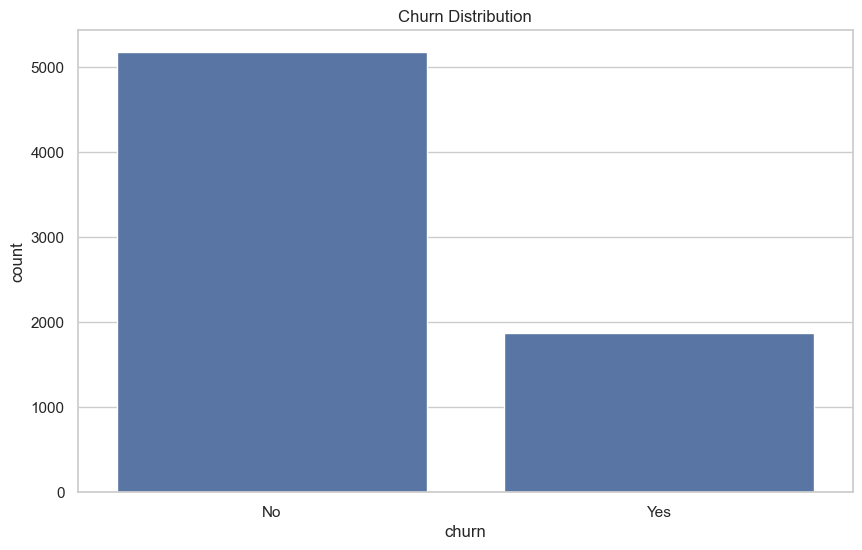

In [234]:
# Baseline churn rate — every other rate in this analysis should be read
# relative to this number (26.5%), not in isolation.

sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

In [21]:
print(df["churn"].value_counts(normalize=True) * 100)

churn
0    73.550776
1    26.449224
Name: proportion, dtype: float64


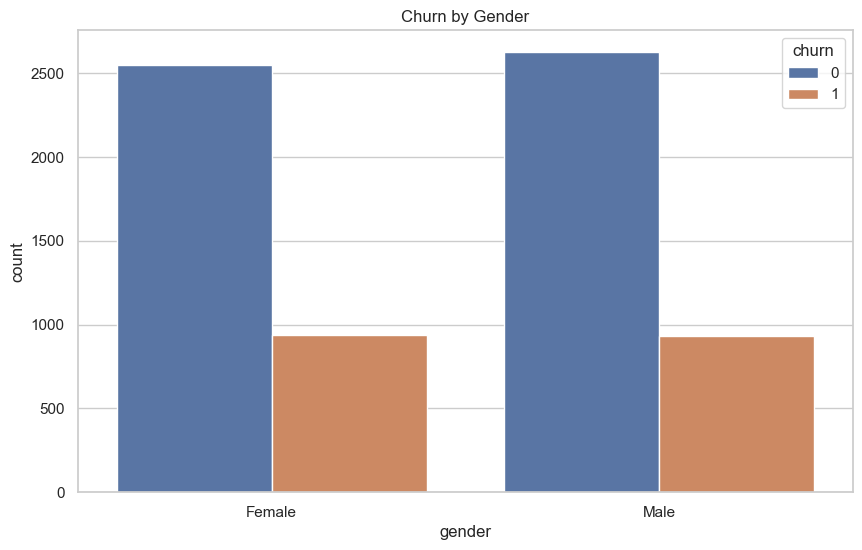

In [236]:
# Demographic cuts — checked first because they're easy "is this even
# usable" sanity checks. Gender turns out to have almost no relationship
# with churn (expected — there's no business reason it should).

sns.countplot(x="gender", hue="churn", data=df)
plt.title("Churn by Gender")
plt.show()

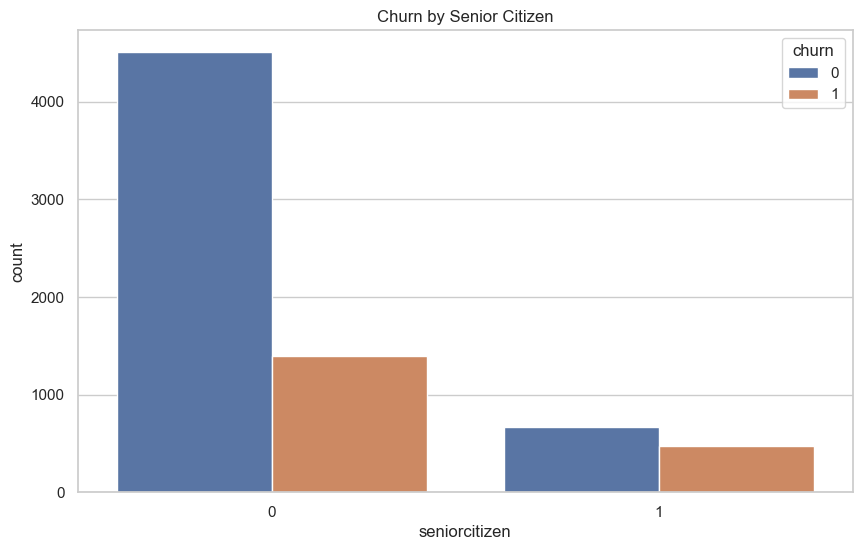

In [238]:
# Senior citizens churn at a noticeably higher rate than non-seniors,
# proportionally — a real, usable signal even though seniors are a
# minority of the base.

sns.countplot(x="seniorcitizen", hue="churn", data=df)
plt.title("Churn by Senior Citizen")
plt.show()

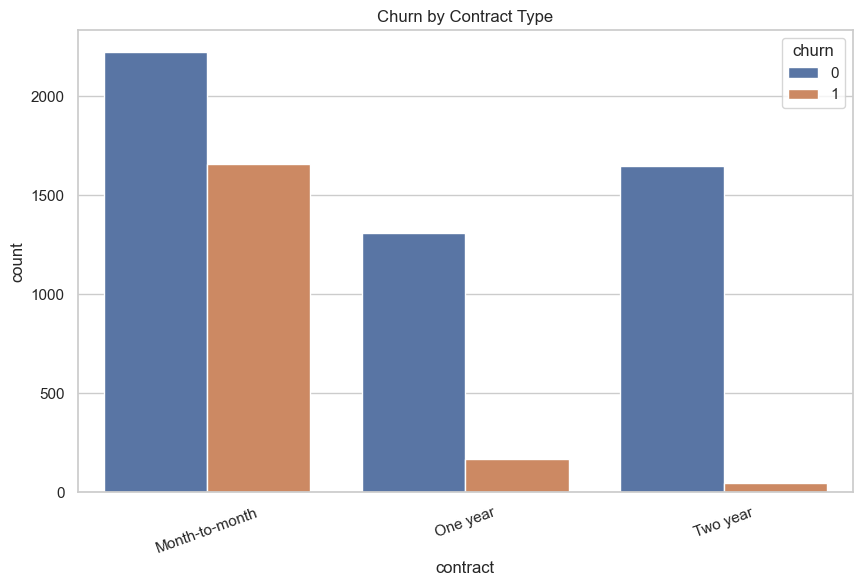

In [240]:
# Contract type — checked because shorter commitment should intuitively
# correlate with easier churn. The chart confirms this is one of the
# strongest signals in the whole dataset.


sns.countplot(x="contract", hue="churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

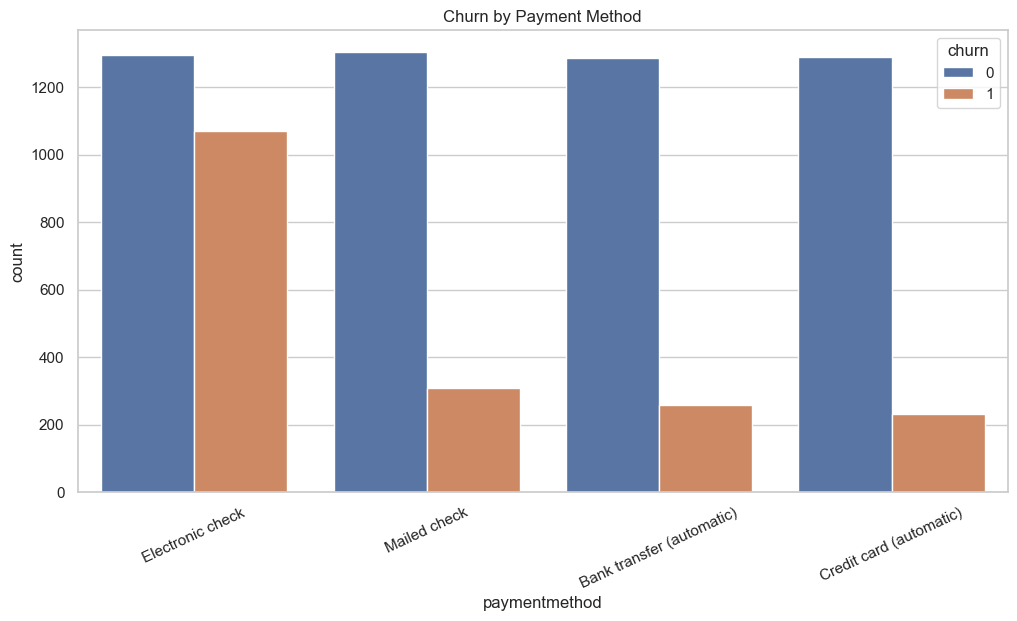

In [242]:
# Payment method — electronic check stands out, which is a useful
# operational lever (encourage autopay) rather than just a demographic fact.

plt.figure(figsize=(12, 6))
sns.countplot(x="paymentmethod", hue="churn", data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=25)
plt.show()

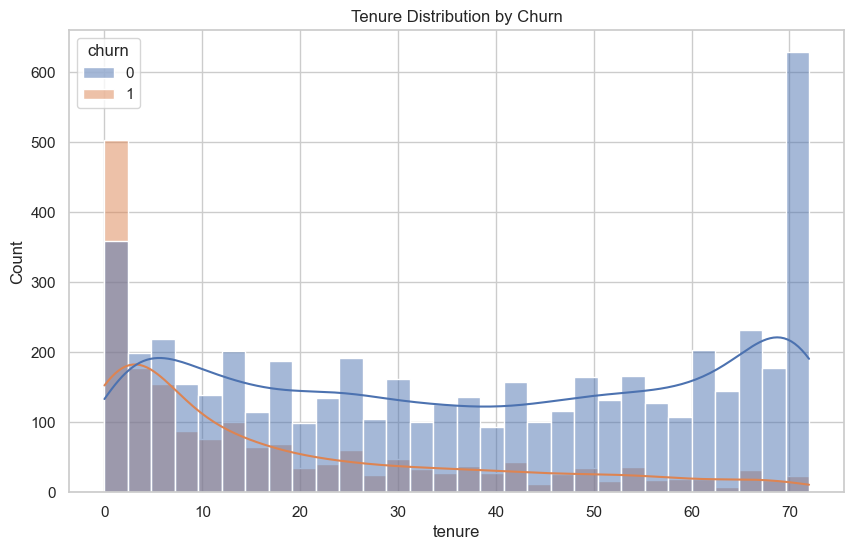

In [244]:
# Tenure distribution split by churn — shows churn concentrated heavily in
# the first few months, which matters for when to intervene, not just who.

sns.histplot(data=df, x="tenure", hue="churn", bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

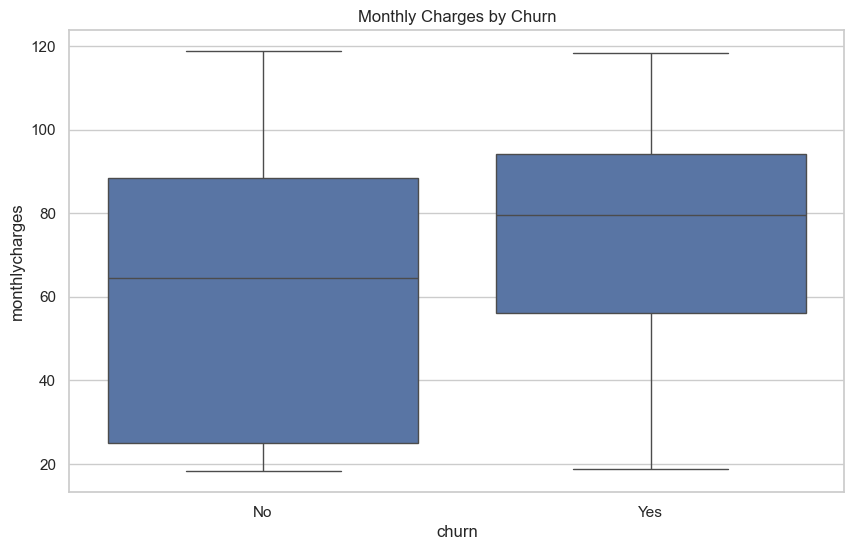

In [246]:
# Monthly charges by churn — churners trend toward paying more per month.

sns.boxplot(x="churn", y="monthlycharges", data=df)
plt.title("Monthly Charges by Churn")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

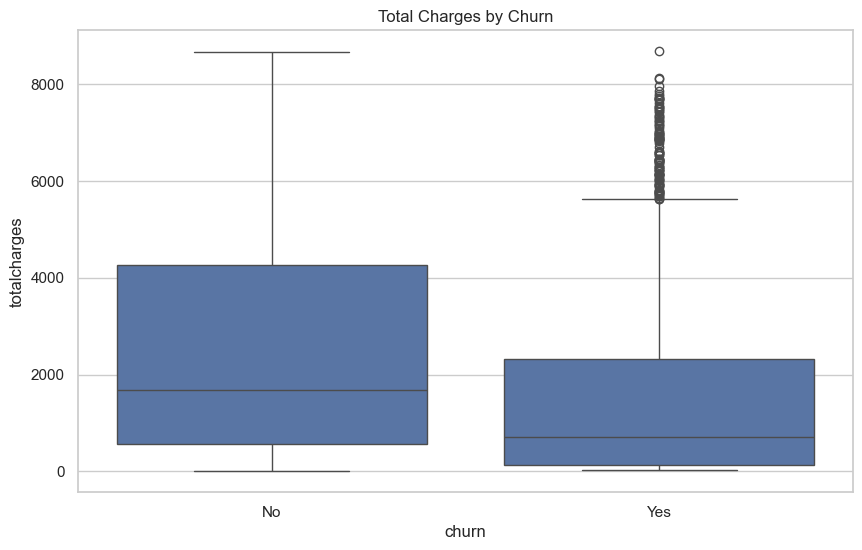

In [248]:
# Total charges by churn — churners show LOWER total charges, which looks
# like it contradicts the monthly-charges chart above, but it doesn't:
# total charges = tenure x monthly charges, and churners have much shorter
# tenure. This is tenure dominating the total, not a pricing effect.

sns.boxplot(x="churn", y="totalcharges", data=df)
plt.title("Total Charges by Churn")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

In [250]:
# Turning the EDA chart above into an actual rate makes the contract effect
# concrete and quotable: month-to-month customers churn at >15x the rate of
# two-year customers.

contract_churn = df.groupby("contract")["churn"].mean().sort_values(ascending=False)
print(contract_churn)

contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: churn, dtype: float64


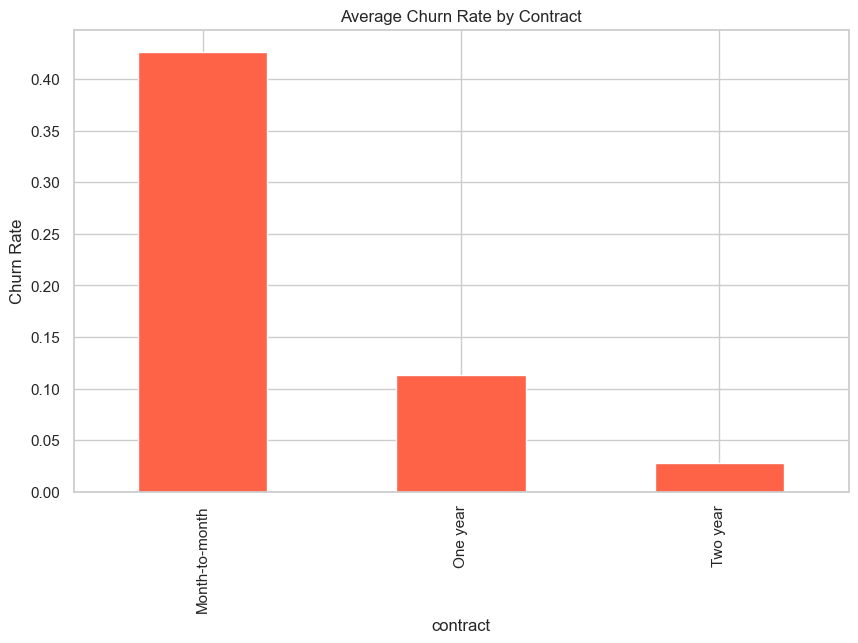

In [30]:
contract_churn.plot(kind="bar", color="tomato")
plt.title("Average Churn Rate by Contract")
plt.ylabel("Churn Rate")
plt.show()

In [252]:
# Same idea for internet service type — fiber optic customers churn at
# more than double the DSL rate, which is unusual enough to be worth a
# business-side investigation (pricing vs. service quality vs. competition).

internet_churn = df.groupby("internetservice")["churn"].mean().sort_values(ascending=False)
print(internet_churn)

internetservice
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: churn, dtype: float64


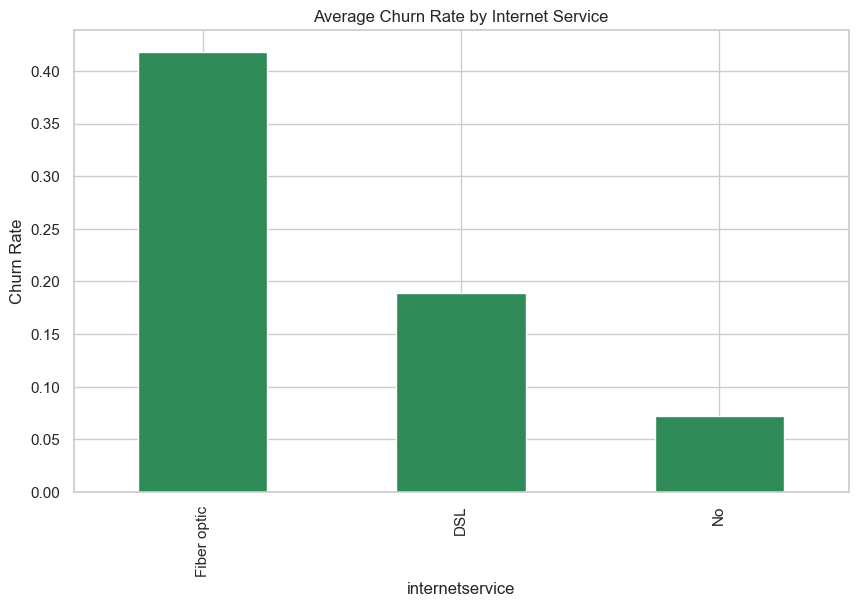

In [32]:
internet_churn.plot(kind="bar", color="seagreen")
plt.title("Average Churn Rate by Internet Service")
plt.ylabel("Churn Rate")
plt.show()

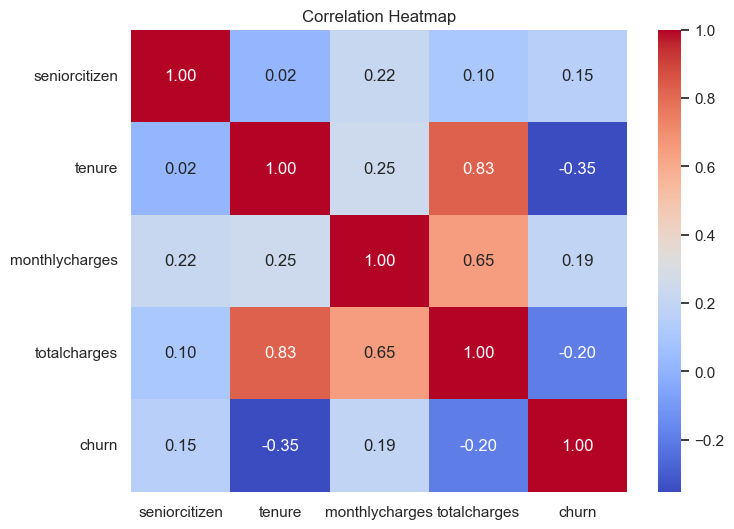

In [254]:
# Correlation heatmap across the numeric columns only — useful for spotting
# both (a) churn's strongest numeric relationships and (b) multicollinearity
# between predictors (tenure vs totalcharges here, r = 0.83) that will matter
# when interpreting model coefficients later.

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [34]:
# Saving the cleaned dataset so modeling can start from a fixed, versioned
# snapshot rather than re-running the cleaning steps every time.

df.to_csv("telco_churn_cleaned.csv", index=False)

# Preprocessing & Train/Test Split

In [35]:
X = df.drop(columns=["churn"])
y = df["churn"]

In [36]:
# Split columns by dtype so numeric and categorical features can go through
# different preprocessing (scaling vs. one-hot encoding) inside one pipeline.

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']
Numerical columns: ['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges']


/var/folders/yf/8b3lcg_x1kq3__3n6g7jtm2h0000gn/T/ipykernel_79830/2594031992.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [257]:
# StandardScaler matters most for logistic regression (and any
# distance/gradient-based model) since features are on very different
# scales (e.g. tenure 0-72 vs monthlycharges ~20-120).

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])
# drop="first" avoids the "dummy variable trap" (perfectly collinear
# one-hot columns), which keeps linear-model coefficients identifiable.
# handle_unknown="ignore" prevents the encoder from crashing if test data
# ever contains a category not seen during training.

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# NOTE: this single `preprocessor` object is reused (not cloned) inside every
# Pipeline below. sklearn's Pipeline does not clone its steps, so each
# `.fit()` call re-fits this same shared object. It happens to be harmless
# here because every pipeline is fit on the same X_train — but if any
# pipeline were later fit on a different subset of data, the others would
# silently end up holding the wrong fitted preprocessing state. Safer
# practice for production code: build a fresh ColumnTransformer (or use
# sklearn.base.clone(preprocessor)) per model.

In [39]:
from sklearn.model_selection import train_test_split

In [259]:
# stratify=y keeps the ~73.5% / 26.5% class split consistent between train
# and test — without it, a random split could over- or under-represent
# churners in the test set and make metrics misleading.


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5616, 19)
X_test: (1405, 19)
y_train: (5616,)
y_test: (1405,)


# Modeling

#### Three models are compared: Logistic Regression (simple, interpretable baseline), Random Forest (non-linear, handles interactions), and XGBoost (gradient boosting, usually the strongest off-the-shelf option). Comparing all three checks whether the extra complexity of RF/XGBoost is actually earning its keep on this dataset.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [267]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# max_iter raised because
    # the default (100) sometimes fails to converge once one-hot encoding
    # expands the feature space.

In [269]:
log_reg_model.fit(X_train, y_train)
y_pred = log_reg_model.predict(X_test)
y_prob = log_reg_model.predict_proba(X_test)[:, 1]

# probability of churn=1, needed for ROC-AUC/segmentation

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8021352313167259
ROC-AUC: 0.8403530275114762

Confusion Matrix:
 [[933 100]
 [178 194]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.79      1405



In [47]:
from sklearn.ensemble import RandomForestClassifier

In [271]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
         # up-weights the minority (churn=1) class
        # during training, since churners are only ~26.5% of the data and a
        # default-weighted model would be biased toward predicting "no churn".
    ))
])

In [273]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [275]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Accuracy: 0.7786476868327402
ROC-AUC: 0.8185509893930406

Confusion Matrix:
 [[931 102]
 [209 163]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.44      0.51       372

    accuracy                           0.78      1405
   macro avg       0.72      0.67      0.68      1405
weighted avg       0.76      0.78      0.77      1405



In [52]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.802135,0.840353
1,Random Forest,0.783630,0.818848


# Feature Importance

In [54]:
import numpy as np
import pandas as pd

In [55]:
feature_names = preprocessor.get_feature_names_out()

In [56]:
# Re-fitting here is redundant (log_reg_model was already fit above on the
# same X_train/y_train) but harmless — kept to mirror the original notebook
# and to guarantee the fitted classifier object below is in sync with
# `feature_names`.

log_reg_model.fit(X_train, y_train)
coefficients = log_reg_model.named_steps["classifier"].coef_[0]

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['seniorcitizen', 'tenure',
                                                   'monthlycharges',
                                                   'totalcharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'partner',
                                                   'dependents', 'phoneservice',
                                                   'multiplelines',
                                                   'internetservice',
                                                   'onlinesecurity',
                                                   'onlinebackup',
                                                   'deviceprotection',
                                                   'techsupport', 'streamingtv',
                                                   'streamingmovies',
                                                   'contract',
                                                   'paperlessbilling',
                                                   'paymentmethod'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [58]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

In [277]:
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
coef_df.head(15)

# NOTE on reading these coefficients: tenure and totalcharges are highly
# correlated (r = 0.83, see the heatmap above). When two correlated features
# are both in a linear model, their individual coefficients can flip sign or
# look "backwards" relative to their raw, univariate relationship with churn
# (e.g. totalcharges correlates negatively with churn on its own, but shows a
# positive coefficient here once tenure is already in the model). Read these
# as "marginal effect holding the other features fixed", not as the
# headline relationship — the raw groupby() rates above are more intuitive
# for a non-technical audience.

,feature,coefficient,abs_coefficient
1,num__tenure,-1.403159,1.403159
25,cat__contract_Two year,-1.321314,1.321314
10,cat__internetservice_Fiber optic,1.003327,1.003327
3,num__totalcharges,0.658879,0.658879
24,cat__contract_One year,-0.655552,0.655552
7,cat__phoneservice_Yes,-0.559486,0.559486
26,cat__paperlessbilling_Yes,0.338351,0.338351
9,cat__multiplelines_Yes,0.329355,0.329355
13,cat__onlinesecurity_Yes,-0.328380,0.328380
28,cat__paymentmethod_Electronic check,0.313583,0.313583


/var/folders/yf/8b3lcg_x1kq3__3n6g7jtm2h0000gn/T/ipykernel_79830/493573647.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coef, x="coefficient", y="feature", palette="coolwarm")


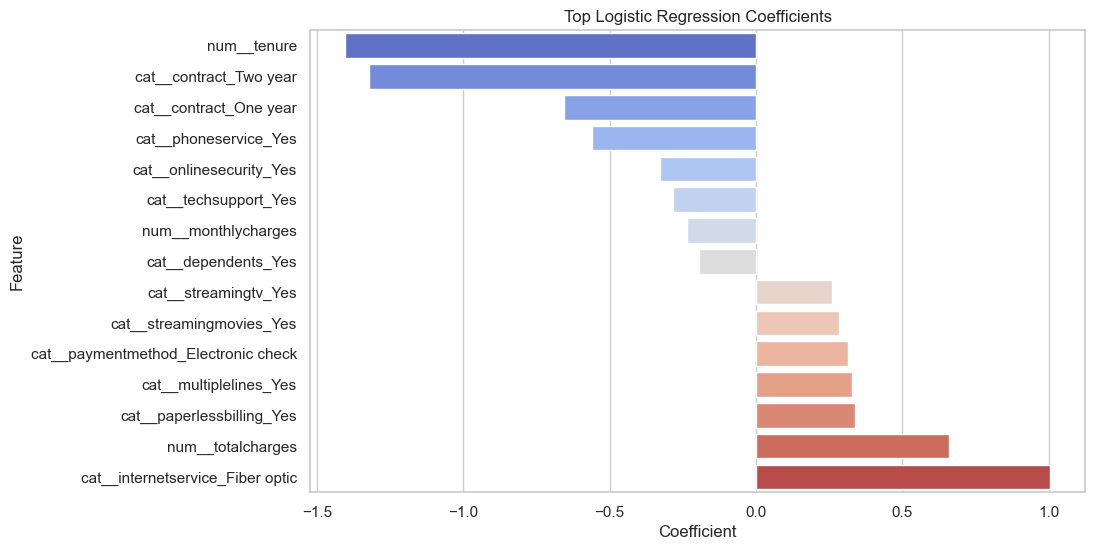

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 15
top_coef = coef_df.head(top_n).sort_values("coefficient")

plt.figure(figsize=(10, 6))
sns.barplot(data=top_coef, x="coefficient", y="feature", palette="coolwarm")
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

# Model Comparison: ROC, Precision-Recall, Cross-Validation

# ROC Curve

In [62]:
from sklearn.metrics import roc_curve, auc

In [63]:
y_prob_log = log_reg_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [64]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)

# ROC-AUC is used (rather than accuracy alone) because accuracy can look
# artificially good on an imbalanced target just by predicting the majority
# class — ROC-AUC measures ranking quality across all thresholds instead.

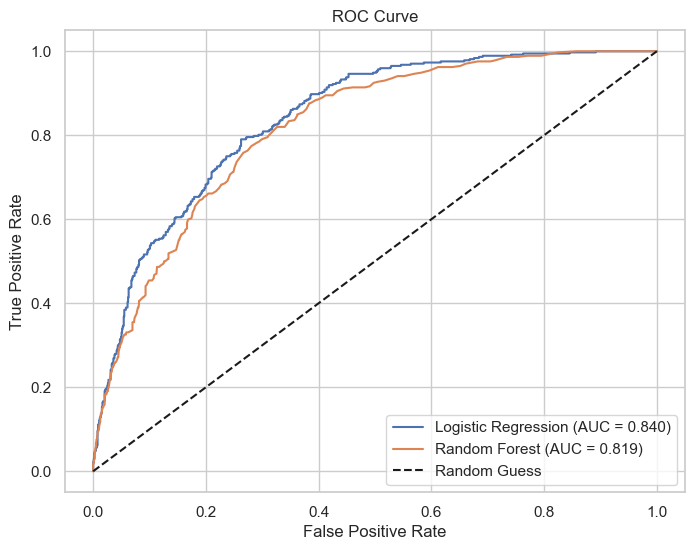

In [65]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve

In [67]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [68]:
precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob_log)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

ap_log = average_precision_score(y_test, y_prob_log)
ap_rf = average_precision_score(y_test, y_prob_rf)

# Precision-Recall is the more honest curve for an imbalanced target like
# this one (26.5% positive class) — ROC-AUC can look optimistic on
# imbalanced data because the false-positive-rate denominator is dominated
# by the large negative class.

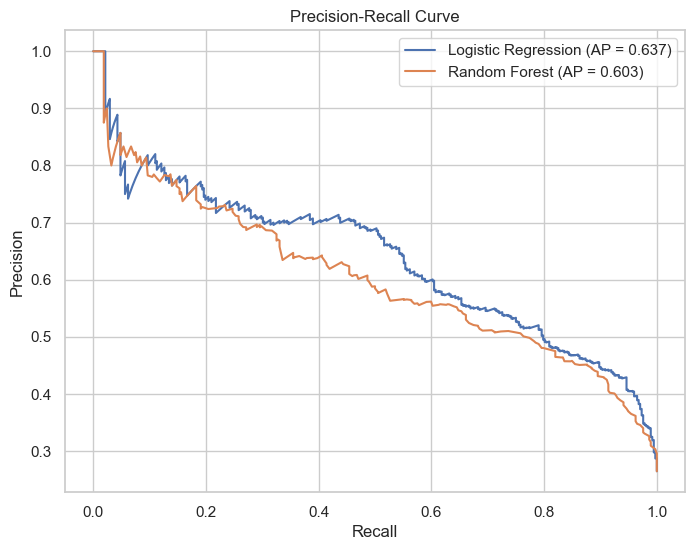

In [69]:
plt.figure(figsize=(8, 6))
plt.plot(recall_log, precision_log, label=f"Logistic Regression (AP = {ap_log:.3f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (AP = {ap_rf:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Cross Validation

In [71]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [72]:
# A single train/test split can be lucky or unlucky. 5-fold cross-validation
# checks whether the test-set result generalizes, rather than reflecting one
# specific split. StratifiedKFold keeps the 73.5/26.5 class ratio in every
# fold, same reasoning as the stratified train_test_split above.


log_cv_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_log = cross_val_score(
    log_cv_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression CV F1 Scores:", cv_scores_log)
print("Mean F1 Score:", cv_scores_log.mean())
print("Std F1 Score:", cv_scores_log.std())

Logistic Regression CV F1 Scores: [0.61560694 0.58630952 0.60792952 0.57388809 0.5852187 ]
Mean F1 Score: 0.5937905540664135
Std F1 Score: 0.0155010658797673


In [73]:
rf_cv_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

cv_scores_rf = cross_val_score(
    rf_cv_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("Random Forest CV F1 Scores:", cv_scores_rf)
print("Mean F1 Score:", cv_scores_rf.mean())
print("Std F1 Score:", cv_scores_rf.std())

# F1 (not accuracy) is used as the CV scoring metric because it balances
# precision and recall on the minority "churn" class specifically — the
# metric that matters for a retention use case is "did we catch the
# churners", not "are we right overall".

Random Forest CV F1 Scores: [0.57709924 0.55399061 0.50552923 0.55120482 0.52598425]
Mean F1 Score: 0.542761628824769
Std F1 Score: 0.024674606389124915


# XGBoost

In [75]:
pip install xgboost==2.1.4

Note: you may need to restart the kernel to use updated packages.


In [76]:
from xgboost import XGBClassifier

In [77]:
# Added as a third model because gradient boosting is usually the strongest
# off-the-shelf classifier for structured/tabular data like this — useful to
# confirm (or disconfirm) that with logistic regression and random forest.

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,   # kept shallow on purpose — deep trees overfit
        # easily on a dataset this size (~7k rows) given XGBoost's added
        # flexibility relative to a single Random Forest tree.
        subsample=0.8,
        colsample_bytree=0.8,   # subsample / colsample_bytree add randomness
        # per boosting round, which reduces overfitting in the same spirit
        # as bagging in Random Forest.
        random_state=42,
        eval_metric="logloss"
    ))
])

In [78]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['seniorcitizen', 'tenure',
                                                   'monthlycharges',
                                                   'totalcharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'partner',
                                                   'dependents', 'phoneservice',
                                                   'multiplelines',
                                                   'internetservice',
                                                   'on...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [79]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [80]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.7864768683274022
ROC-AUC: 0.8341595623978598

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       372

    accuracy                           0.79      1405
   macro avg       0.73      0.69      0.70      1405
weighted avg       0.77      0.79      0.78      1405



# SHAP Analysis

In [82]:
pip install shap==0.45.1 --no-deps

Note: you may need to restart the kernel to use updated packages.


In [83]:
import shap

In [84]:
# SHAP needs the data already preprocessed (numeric matrix), so the
# ColumnTransformer is applied here outside of the Pipeline wrapper.
#
# NOTE: `preprocessor.fit_transform(X_train)` re-fits the *same* shared
# `preprocessor` object used inside log_reg_model / rf_model / xgb_model
# above (see the NOTE in Section 5). Because it's fit on the same X_train
# again here, the encoded columns end up identical either way — but this is
# exactly the kind of shared-mutable-state pattern that causes hard-to-spot
# bugs if the code changes later. A cleaner version would create a separate
# ColumnTransformer instance for this SHAP step.


X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [85]:
feature_names = preprocessor.get_feature_names_out()

In [86]:
# A standalone XGBClassifier (not wrapped in a Pipeline) is fit directly on
# the already-transformed data because shap.TreeExplainer needs direct
# access to the raw booster — it can't introspect through a Pipeline step.


xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [87]:
xgb.fit(X_train_transformed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [88]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_transformed)

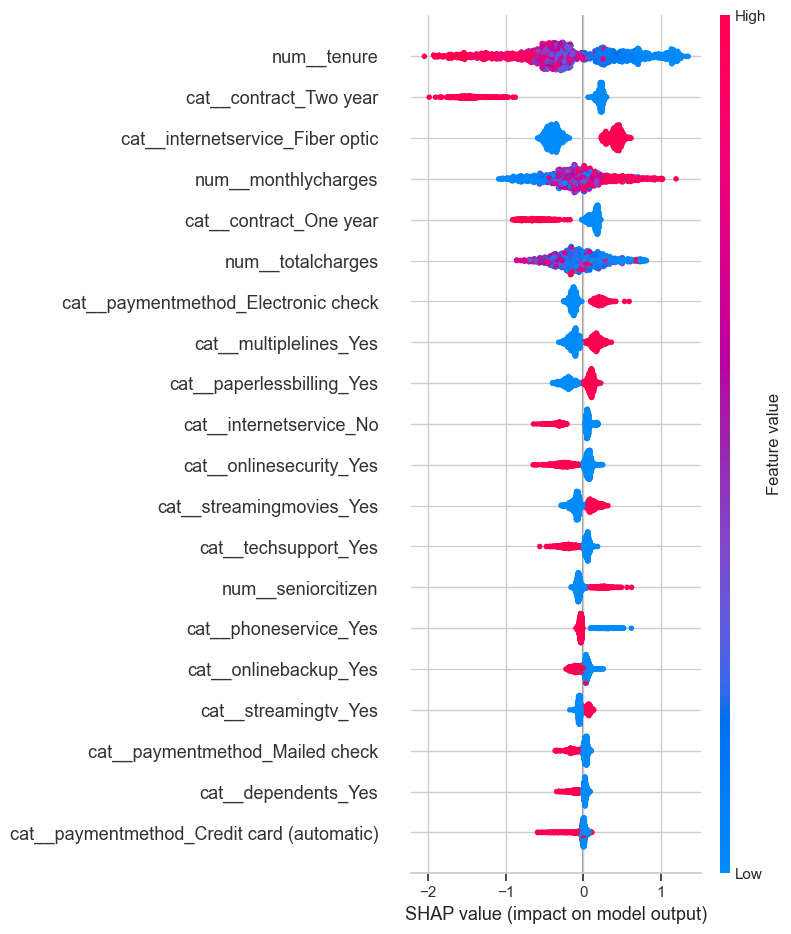

In [89]:
# The summary plot shows, across every test customer, which features push
# predictions toward "churn" (red, high feature value) vs "stay" (blue) —
# this is the tree-based equivalent of the logistic regression coefficients
# above, and is used here as a cross-check: if both methods agree on the
# top drivers, that's a much stronger signal than either one alone.


shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [90]:
# A force plot for a single customer (row 0 of the test set) shows exactly
# why the model gave *that customer* their specific churn probability —
# useful for explaining an individual high-risk flag to a retention agent,
# as opposed to the summary plot's dataset-wide view.


shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_transformed[0],
    feature_names=feature_names
)

# Customer Risk Segmentation

In [280]:
# Converts the model's raw probability output into a 3-tier label
# (Low / Medium / High risk) that's easier for a retention team to act on
# than a raw probability number.


all_probs = log_reg_model.predict_proba(X)[:, 1]

In [93]:
risk_df = X_test.copy()
risk_df["actual_churn"] = y_test.values
risk_df["churn_probability"] = y_prob_log   # logistic regression chosen here since
# it had the best ROC-AUC/CV-F1 of the three models.

In [282]:
def assign_risk(prob):

    """Bucket a churn probability into a business-friendly risk tier.
 
    Thresholds (0.20 / 0.50) are a simple, round-number starting point, not
    a value tuned against a cost-benefit analysis. Before using these tiers
    to drive real retention spend, they're worth revisiting against the
    actual cost of an intervention vs. the cost of losing a customer.
    """
    if prob < 0.20:
        return "Low Risk"
    elif prob <= 0.50:
        return "Medium Risk"
    else:
        return "High Risk"

In [95]:
risk_df["risk_level"] = risk_df["churn_probability"].apply(assign_risk)

In [96]:
risk_df[["churn_probability", "risk_level"]].head(10)

,churn_probability,risk_level
5627,0.759308,High Risk
6126,0.615998,High Risk
2361,0.285743,Medium Risk
2201,0.049462,Low Risk
832,0.008949,Low Risk
683,0.326745,Medium Risk
3403,0.154221,Low Risk
6240,0.789557,High Risk
3996,0.018270,Low Risk
4285,0.015394,Low Risk


In [97]:
risk_counts = risk_df["risk_level"].value_counts()
risk_percent = risk_df["risk_level"].value_counts(normalize=True) * 100

print(risk_counts)
print(risk_percent.round(2))

risk_level
Low Risk       736
Medium Risk    375
High Risk      294
Name: count, dtype: int64
risk_level
Low Risk       52.38
Medium Risk    26.69
High Risk      20.93
Name: proportion, dtype: float64


In [98]:
high_risk_pct = (risk_df["risk_level"] == "High Risk").mean() * 100
print(f"{high_risk_pct:.1f}% of customers fall into the high-risk segment.")

20.9% of customers fall into the high-risk segment.


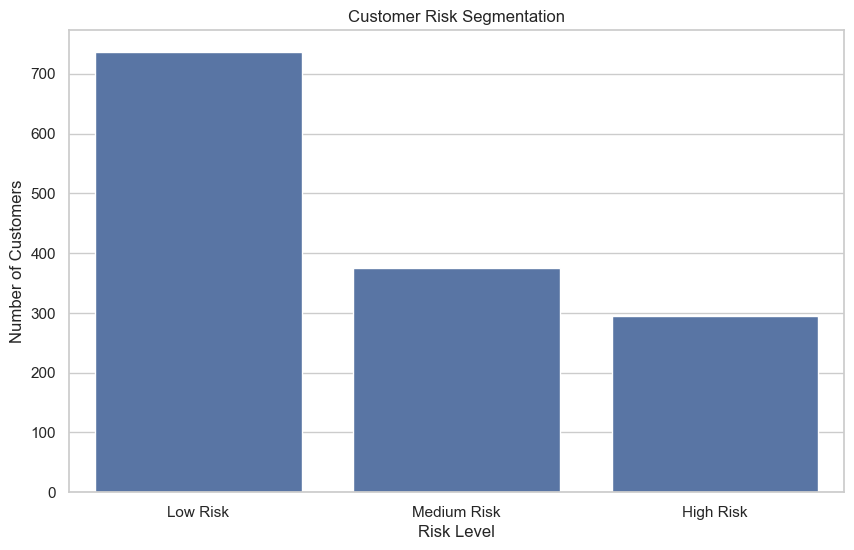

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="risk_level", data=risk_df, order=["Low Risk", "Medium Risk", "High Risk"])
plt.title("Customer Risk Segmentation")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.show()

In [100]:
summary = risk_df["risk_level"].value_counts().reset_index()
summary.columns = ["Risk Level", "Customer Count"]
summary["Percentage"] = summary["Customer Count"] / summary["Customer Count"].sum() * 100
summary

,Risk Level,Customer Count,Percentage
0,Low Risk,736,52.384342
1,Medium Risk,375,26.690391
2,High Risk,294,20.925267


In [284]:
# Finally, score the FULL dataset (not just the held-out test set) — this is
# the number that matters operationally, since the retention team needs to
# act on every current customer, not just the ~1,400 in the test split.


full_probs = log_reg_model.predict_proba(X)[:, 1]

full_risk_df = X.copy()
full_risk_df["churn_probability"] = full_probs
full_risk_df["risk_level"] = full_risk_df["churn_probability"].apply(assign_risk)

In [102]:
full_high_risk_pct = (full_risk_df["risk_level"] == "High Risk").mean() * 100
print(f"{full_high_risk_pct:.1f}% of customers fall into the high-risk segment.")

21.9% of customers fall into the high-risk segment.
